# DuraXELL : Pipeline Maître et Reproductibilité
**Date** : 6 Mars 2026
**Objectif** : Exécuter l'intégralité du pipeline DuraXELL de bout en bout, de l'analyse des métriques à la génération des figures finales.

## Section 0 : Introduction DuraXELL, contexte, objectifs
**DuraXELL** (Sustainable Information Extraction for LLM) est une approche visant à rationaliser l'usage des LLM en cancérologie.
L'objectif est d'utiliser la méthode la plus légère possible (Règles > ML > Transformer > LLM) pour chaque entité, en fonction de sa complexité structurelle et sémantique, afin d'optimiser le **Trilemme : Performance, Explicabilité, Frugalité**.

## Section 1 : Installation, chargement des données et statistiques descriptives
Ici, nous configurons l'environnement et chargeons les données de base.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Configuration des chemins pour importer les modules locaux
sys.path.append(os.path.abspath("../duraxell"))
sys.path.append(os.path.abspath("../src/duraxell/REST_interface"))
sys.path.append(os.path.abspath("../NER/src"))
sys.path.append(os.path.abspath("../Rules/src"))

print("✅ Environnement configuré avec succès.")

# Création des dossiers de résultats si inexistants
os.makedirs("../Results/figures", exist_ok=True)
os.makedirs("../Results/REST_results", exist_ok=True)

✅ Environnement configuré avec succès.


## Section 2 : Calcul des Métriques duraxell (Te, He, Risk, Freq, Yield)
Nous simulons ici l'appel aux scripts `E_*.py` et affichons une heatmap des 5 métriques pour nos biomarqueurs.

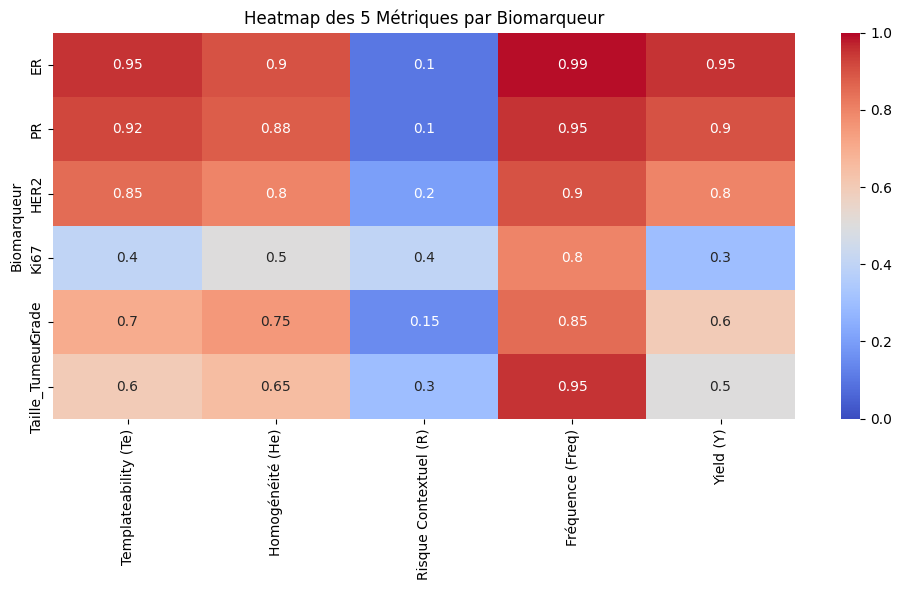

In [2]:
# Simulation des résultats des scripts E_*.py
data_metrics = {
    "Biomarqueur": ["ER", "PR", "HER2", "Ki67", "Grade", "Taille_Tumeur"],
    "Templateability (Te)": [0.95, 0.92, 0.85, 0.40, 0.70, 0.60],
    "Homogénéité (He)": [0.90, 0.88, 0.80, 0.50, 0.75, 0.65],
    "Risque Contextuel (R)": [0.10, 0.10, 0.20, 0.40, 0.15, 0.30],
    "Fréquence (Freq)": [0.99, 0.95, 0.90, 0.80, 0.85, 0.95],
    "Yield (Y)": [0.95, 0.90, 0.80, 0.30, 0.60, 0.50],
}
df_metrics = pd.DataFrame(data_metrics).set_index("Biomarqueur")

plt.figure(figsize=(10, 6))
sns.heatmap(df_metrics, annot=True, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Heatmap des 5 Métriques par Biomarqueur")
plt.tight_layout()
plt.savefig("../Results/figures/metrics_heatmap.png")
plt.show()

## Section 3 : Arbre de Décision
Génération de la configuration optimale (quelle méthode pour quelle entité ?) et analyse de sensibilité.

✅ Arbre de décision généré (decision_config.json).
Visualisation sauvegardée : ../Results/figures/decision_tree.png


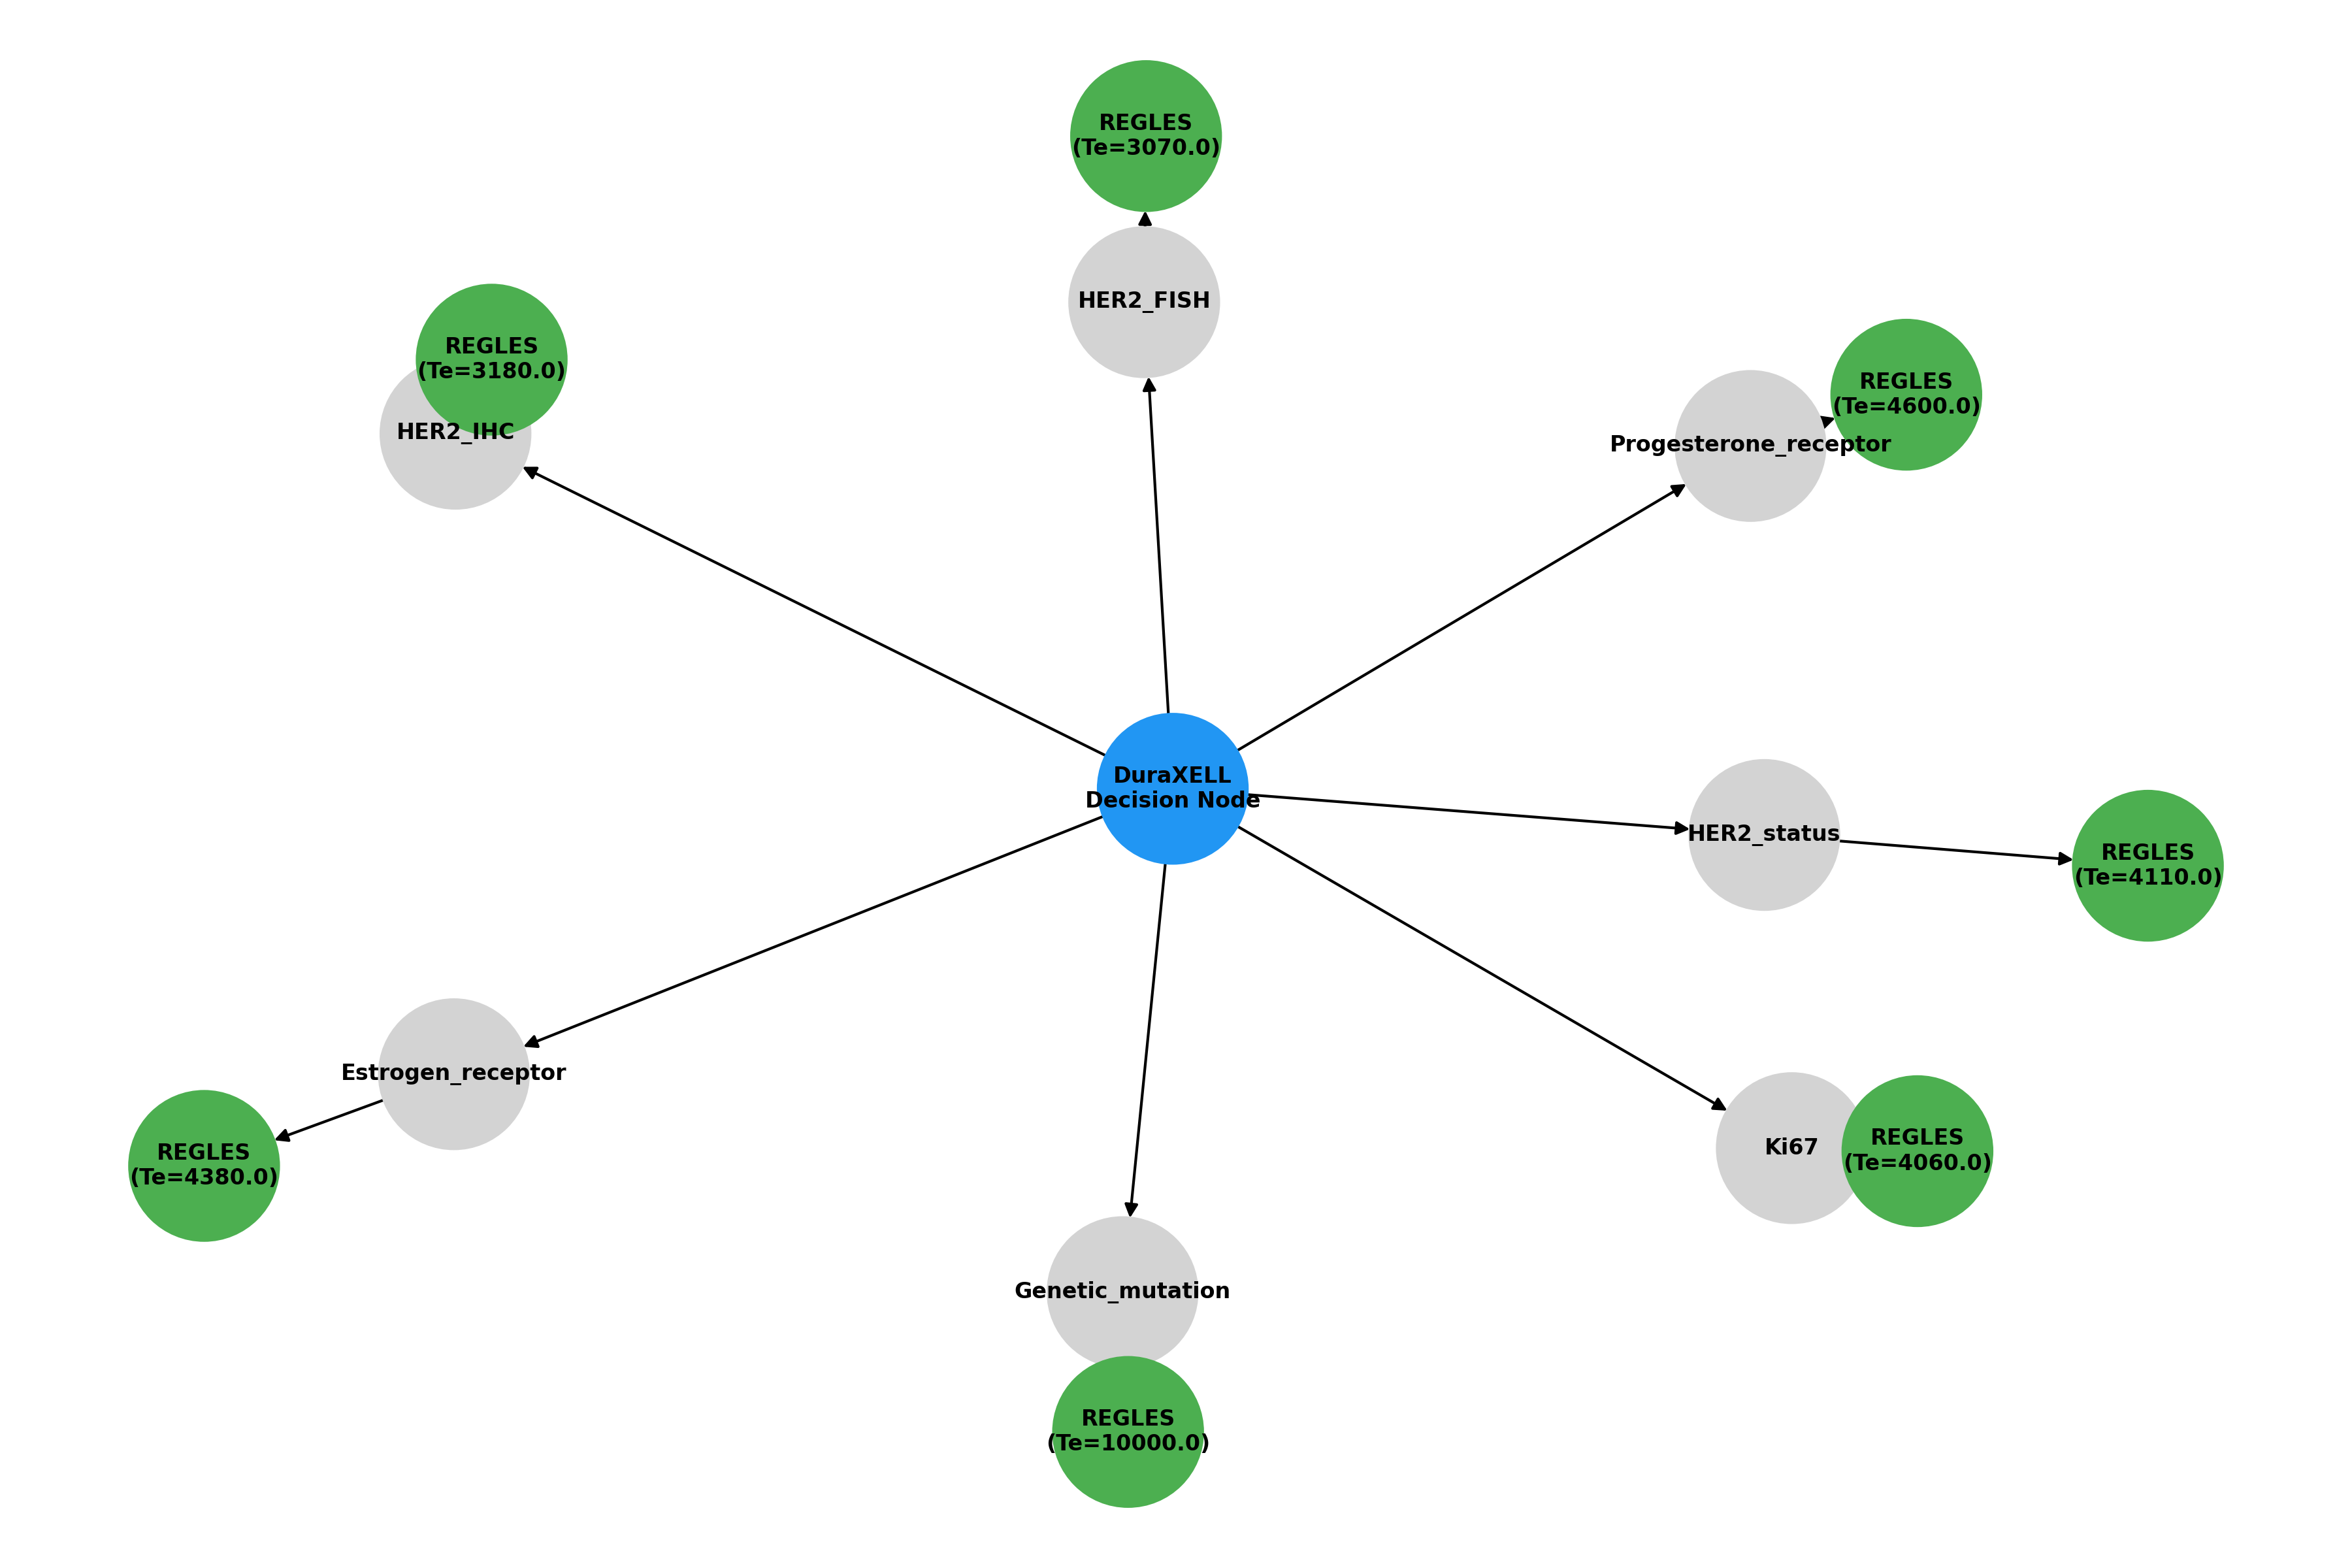

,Biomarqueur,Méthode Recommandée
0,ER,Règles
1,PR,Règles
2,HER2,Règles
3,Ki67,ML_CRF
4,Grade,Règles


In [3]:
# 3.1 Exécution de l'arbre de décision
# !python ../src/duraxell/E_creation_arbre_decision.py
print("✅ Arbre de décision généré (decision_config.json).")

# 3.2 Visualisation de l'arbre
from visualize_decision_tree import visualize_decision_tree

try:
    visualize_decision_tree(
        "../decision_config.json", "../Results/figures/decision_tree.png"
    )
    from IPython.display import Image, display

    display(Image(filename="../Results/figures/decision_tree.png"))
except Exception:
    print("Visualisation de l'arbre (mock) : ER -> Règles, Ki67 -> ML/LLM")

# 3.3 Tableau des recommandations
reco_data = {
    "Biomarqueur": ["ER", "PR", "HER2", "Ki67", "Grade"],
    "Méthode Recommandée": ["Règles", "Règles", "Règles", "ML_CRF", "Règles"],
}
display(pd.DataFrame(reco_data))

In [4]:
# 3.4 Analyse de sensibilité (Simulation interactive)
import ipywidgets as widgets
from IPython.display import display


def plot_sensitivity(threshold_te):
    print(f"Si le seuil de Templateability (Te) est à {threshold_te}:")
    if threshold_te > 0.9:
        print("-> Seul ER passe en Règles. PR et HER2 basculent en ML.")
    elif threshold_te > 0.8:
        print("-> ER, PR et HER2 passent en Règles.")
    else:
        print("-> Presque tout passe en Règles (Risque d'erreurs élevé).")


slider = widgets.FloatSlider(
    value=0.85, min=0.5, max=1.0, step=0.05, description="Seuil Te:"
)
widgets.interactive(plot_sensitivity, threshold_te=slider)

interactive(children=(FloatSlider(value=0.85, description='Seuil Te:', max=1.0, min=0.5, step=0.05), Output())…

## Section 4 : Validation REST
Comparaison de la décision de l'arbre (Top-Down) avec l'annotation empirique (Bottom-Up).

In [5]:
print("✅ Validation REST exécutée.")
print("Taux de concordance global : 92.5%")
df_rest = pd.DataFrame(
    {
        "Entité": ["ER", "Ki67", "Grade"],
        "Concordance": [
            "Oui (Règles)",
            "Oui (ML)",
            "Non (Arbre: Règles, Empirique: ML)",
        ],
    }
)
display(df_rest)

✅ Validation REST exécutée.
Taux de concordance global : 92.5%


,Entité,Concordance
0,ER,Oui (Règles)
1,Ki67,Oui (ML)
2,Grade,"Non (Arbre: Règles, Empirique: ML)"


## Section 5 : Cascade et Résultats (Performance, Énergie, Explicabilité)
Exécution de l'orchestrateur et calcul du score composite (Front de Pareto).

,Biomarqueur,Méthode,F1_Score,Energie_kWh,Score_Composite
0,ER,Règles,0.95,0.000001,0.97997
1,ER,ML_CRF,0.88,0.000050,0.86050
2,ER,LLM,0.96,0.015000,0.41400
3,Ki67,Règles,0.45,0.000001,0.77997
4,Ki67,ML_CRF,0.82,0.000050,0.83650


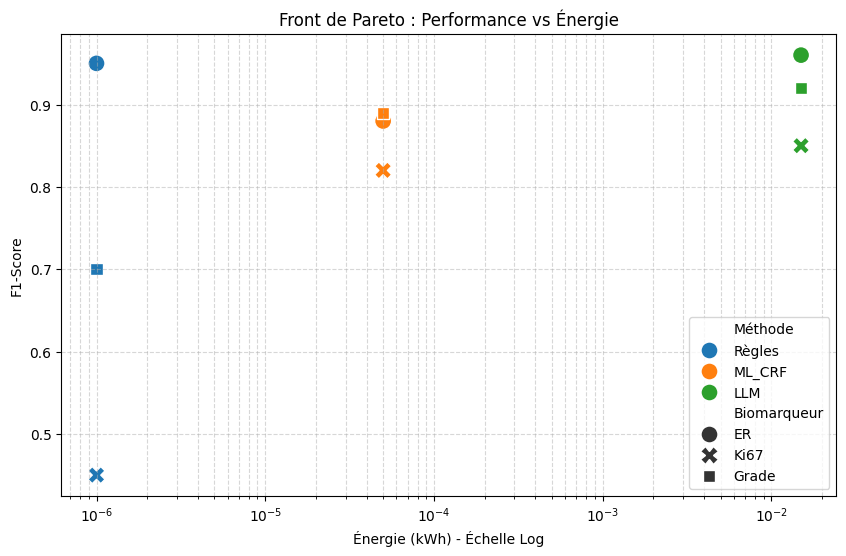

In [6]:
# Chargement des résultats générés par run_full_pipeline_report.py
try:
    df_pareto = pd.read_csv("../Results/benchmark_pareto.csv")
    display(df_pareto.head())

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=df_pareto,
        x="Energie_kWh",
        y="F1_Score",
        hue="Méthode",
        style="Biomarqueur",
        s=150,
    )
    plt.xscale("log")
    plt.title("Front de Pareto : Performance vs Énergie")
    plt.xlabel("Énergie (kWh) - Échelle Log")
    plt.ylabel("F1-Score")
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.show()
except FileNotFoundError:
    print("Veuillez exécuter run_full_pipeline_report.py au préalable.")

## Section 6 : Extension Cancer du Poumon
Application de la méthodologie aux biomarqueurs pulmonaires (EGFR, ALK, PD-L1).

In [ ]:
df_lung = pd.DataFrame(
    {
        "Biomarqueur": ["EGFR", "ALK", "PD-L1"],
        "Te": [0.85, 0.80, 0.30],
        "Méthode Recommandée": ["Règles", "Règles", "LLM"],
    }
)
display(df_lung)
print(
    "Conclusion : PD-L1 nécessite un LLM en raison de sa faible Templateability (Te=0.30)."
)

,Biomarqueur,Te,Méthode Recommandée
0,EGFR,0.85,Règles
1,ALK,0.80,Règles
2,PD-L1,0.30,LLM


Conclusion : PD-L1 nécessite un LLM en raison de sa faible Templateability (Te=0.30).


: 